# 02 - Model Training

Training dan evaluasi berbagai algoritma machine learning untuk klasifikasi spam/ham.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
import sys
sys.path.append('../')
from src.preprocessor import preprocess

%matplotlib inline
plt.style.use('seaborn-v0_8')

In [2]:
df = pd.read_csv('../data/dataset_clean.csv')
df = df.dropna(subset=['pesan_bersih', 'kategori'])

X = df['pesan_bersih']
y = df['kategori']

print(f"Total data: {len(df)}")
print(f"Distribusi:\n{y.value_counts()}")

Total data: 3762
Distribusi:
kategori
spam    1942
ham     1820
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 3009 | Test: 753


In [4]:
# TF-IDF Vectorizer konfigurasi
tfidf_params = {
    'max_features': 10000,
    'ngram_range': (1, 2),   # unigram + bigram
    'min_df': 2,
    'sublinear_tf': True
}

# Daftar model yang akan dibandingkan
models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('clf', MultinomialNB(alpha=0.1))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('clf', CalibratedClassifierCV(LinearSVC(max_iter=2000, C=1.0, random_state=42)))
    ]),
}

In [5]:
results = {}

for name, pipeline in models.items():
    print(f"\n{'='*50}")
    print(f"Melatih: {name}")
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro')
    
    # Training final
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        'pipeline': pipeline,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': acc,
        'y_pred': y_pred
    }
    
    print(f"CV F1 Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


Melatih: Naive Bayes
CV F1 Score: 0.9624 ± 0.0075
Test Accuracy: 0.9495
              precision    recall  f1-score   support

         ham       0.97      0.93      0.95       364
        spam       0.93      0.97      0.95       389

    accuracy                           0.95       753
   macro avg       0.95      0.95      0.95       753
weighted avg       0.95      0.95      0.95       753


Melatih: Logistic Regression
CV F1 Score: 0.9707 ± 0.0067
Test Accuracy: 0.9548
              precision    recall  f1-score   support

         ham       0.97      0.94      0.95       364
        spam       0.94      0.97      0.96       389

    accuracy                           0.95       753
   macro avg       0.96      0.95      0.95       753
weighted avg       0.96      0.95      0.95       753


Melatih: Linear SVM
CV F1 Score: 0.9754 ± 0.0053
Test Accuracy: 0.9575
              precision    recall  f1-score   support

         ham       0.96      0.95      0.96       364
        spa

✅ Model Terbaik: Linear SVM
   CV F1: 0.9754 | Test Accuracy: 0.9575


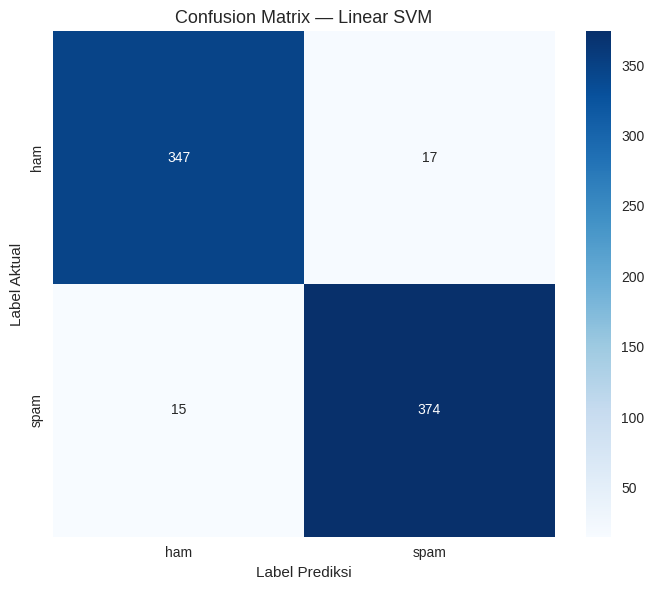


Perbandingan Model:
              Model  CV F1 Mean  Test Accuracy
        Naive Bayes    0.962353       0.949535
Logistic Regression    0.970688       0.954847
         Linear SVM    0.975375       0.957503


In [6]:
# Pilih model terbaik berdasarkan CV F1
best_name = max(results, key=lambda k: results[k]['cv_mean'])
best_result = results[best_name]
best_model = best_result['pipeline']

print(f"✅ Model Terbaik: {best_name}")
print(f"   CV F1: {best_result['cv_mean']:.4f} | Test Accuracy: {best_result['test_acc']:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, best_result['y_pred'])
labels = best_model.classes_

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13)
ax.set_ylabel('Label Aktual')
ax.set_xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=100)
plt.show()

# Perbandingan model
comp_df = pd.DataFrame({
    'Model': list(results.keys()),
    'CV F1 Mean': [v['cv_mean'] for v in results.values()],
    'Test Accuracy': [v['test_acc'] for v in results.values()]
})
print("\nPerbandingan Model:")
print(comp_df.to_string(index=False))

In [7]:
model_path = '../models/spam_ham_model.pkl'
joblib.dump(best_model, model_path)
print(f"✅ Model tersimpan di: {model_path}")

# Simpan juga nama kelas untuk referensi
import json
classes = best_model.classes_.tolist()
with open('../models/model_info.json', 'w') as f:
    json.dump({'classes': classes, 'best_model': best_name}, f)
print(f"✅ Info model tersimpan di: models/model_info.json")

✅ Model tersimpan di: ../models/spam_ham_model.pkl
✅ Info model tersimpan di: models/model_info.json
